<a href="https://colab.research.google.com/github/NatalieAleksandrova2026/Melbourne-housing-DTA/blob/main/notebooks/melbourne_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Melbourne Housing Snapshot





In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)


print("Бібліотеки готові ✅")

Бібліотеки готові ✅


In [14]:
RAW_URL = "https://raw.githubusercontent.com/NatalieAleksandrova2026/Melbourne-housing-DTA/refs/heads/main/data/melb_data.csv"
df = pd.read_csv(RAW_URL)
df_origin = df.copy()

In [15]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [16]:
df.shape

(13580, 21)

In [17]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


Коротке резюме проблем для фіксації в нотатках:
Технічні дублі: Перевірити взаємозв'язок між Rooms та Bedroom2 (в останньому є викид у 20 спалень).

Зміна типів даних: Перевести Postcode з числового типу в текстовий/категоріальний.

Критичні пропуски: BuildingArea (47.5%) та YearBuilt (39.6%) потребують стратегії відновлення даних.

Очищення від аномалій: * Видалити або виправити рік побудови 1196.

Обробити нульові значення в Landsize та BuildingArea.

Дослідити гігантські максимуми в площах (Landsize = 433k, BuildingArea = 44k).

In [18]:
df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,float64


In [19]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

In [20]:
df = df.loc[:, ~df.columns.str.match(r'^Unnamed')]

In [21]:
df['Postcode'] = df['Postcode'].astype('string')

In [22]:
df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,datetime64[ns]
Distance,float64
Postcode,string[python]


`df.isna()` позначає порожні клітинки; `df.isna().sum()` рахує їх по стовпцях, а `df.isna().mean()` дає частку (від 0 до 1, помножте на 100 для відсотків).

In [23]:
df.isna()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
13576,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
13577,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
13578,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [24]:
df.isna().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


In [25]:
missing = (df.isna().mean() * 100).round(1)
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

BuildingArea    47.5
YearBuilt       39.6
CouncilArea     10.1
Car              0.5
dtype: float64


In [27]:
df.describe()

,Rooms,Price,Date,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,2017-01-28 20:25:03.622974976,10.137776,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
min,1.000000,8.500000e+04,2016-01-28 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,2016-09-10 00:00:00,6.100000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,2017-03-04 00:00:00,9.200000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,2017-06-24 00:00:00,13.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,2017-09-23 00:00:00,48.100000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000
std,0.955748,6.393107e+05,NaN,5.868725,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772


In [28]:
print(df[df['Landsize'] > 10000])
print(df[df['BuildingArea'] > 1000])
print(df[df['YearBuilt'] < 1800])

               Suburb                  Address  Rooms Type      Price Method        SellerG       Date  Distance  \
687      Balwyn North              9 Gildan St      3    h  2000000.0     VB            Kay 2016-08-28       9.2   
2084      Collingwood          4/170 Oxford St      3    u   950000.0      S         Jellis 2017-03-04       1.6   
2487   Essendon North              1 Dudley St      3    h  1425000.0      S        McGrath 2017-02-25       9.4   
3750        Maidstone      17/46 Eucalyptus Dr      2    u   352500.0      S  hockingstuart 2017-03-18       9.2   
3942      Maribyrnong          44/2 Horizon Dr      2    u   495000.0      S           Brad 2017-03-18       8.7   
4706   Port Melbourne          36/3 Seisman Pl      2    u  1340000.0     VB       Chisholm 2016-12-03       3.8   
5194        Reservoir             14 Beenak St      3    h   572000.0      S            Ray 2016-04-23      11.2   
5584      South Yarra        413/35 Malcolm St      1    u   315000.0   

In [29]:
df.loc[df['Landsize'] == 0, 'Landsize'] = np.nan
df.loc[df['BuildingArea'] == 0, 'BuildingArea'] = np.nan

In [31]:
df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,datetime64[ns]
Distance,float64
Postcode,string[python]


In [33]:
df.loc[df["YearBuilt"] < 1800, "YearBuilt"] = np.nan

In [34]:
print(df.duplicated().sum())

0


In [35]:
df.shape

(13580, 21)

### Крок 4. Дослідження (EDA)

- **гістограма** показує, як розподілені значення. Для ціни вона зазвичай "скошена" - багато дешевих об'єктів і довгий хвіст дорогих. Якщо взяти логарифм ціни, картинка стає рівнішою.

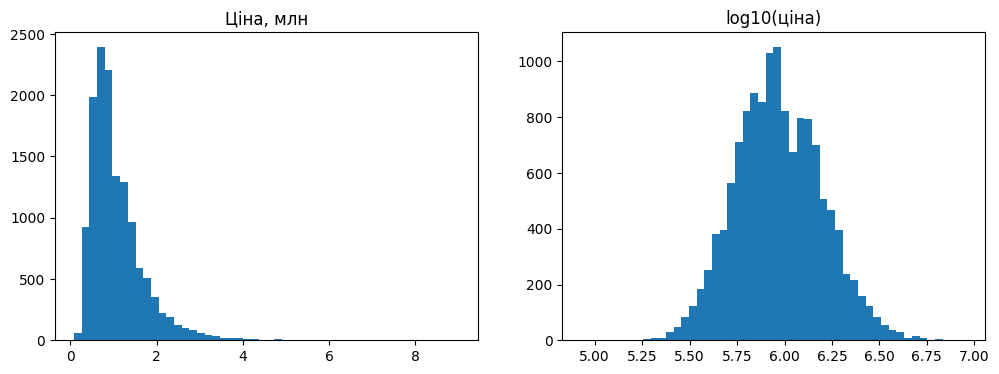

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df["Price"] / 1e6, bins=50)
ax[0].set_title("Ціна, млн")

ax[1].hist(np.log10(df["Price"]), bins=50)
ax[1].set_title("log10(ціна)")

plt.show()

**boxplot за категорією** (наприклад, за типом житла) показує, де ціни вищі, а де нижчі.

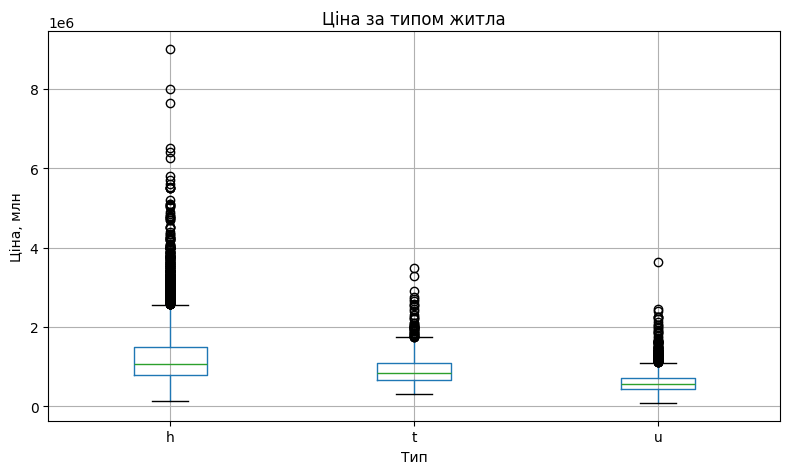

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))

df.boxplot(column='Price', by='Type', ax=ax)

ax.set_title('Ціна за типом житла')
ax.set_xlabel('Тип')
ax.set_ylabel('Ціна, млн')
plt.suptitle('')
plt.tight_layout()
plt.show()

Про **кореляцію** докладніше, бо це важливий інструмент аналітика:
- Знак: `+` означає "разом зростають", `-` означає "коли одне більше, інше менше".
- Сила: чим ближче число до 1 або -1, тим сильніший лінійний зв'язок; близько 0 - зв'язку майже немає. Грубі орієнтири: понад 0.5 - помітний, 0.3-0.5 - помірний, менше 0.2 - слабкий.
- Навіщо: так ви бачите, які ознаки пов'язані з ціною (кандидати у важливі), і знаходите майже однакові ознаки (їх не варто тримати разом).
- Важливо: кореляція бачить лише **лінійні** зв'язки і **не означає причинність**.

In [40]:
num = df.select_dtypes('number')
corr_price = num.corr()['Price'].drop('Price').sort_values(key=abs, ascending=False)
print(corr_price.round(2))

Rooms            0.50
Bedroom2         0.48
Bathroom         0.47
YearBuilt       -0.33
Car              0.24
Lattitude       -0.21
Longtitude       0.20
Distance        -0.16
BuildingArea     0.09
Propertycount   -0.04
Landsize         0.02
Name: Price, dtype: float64


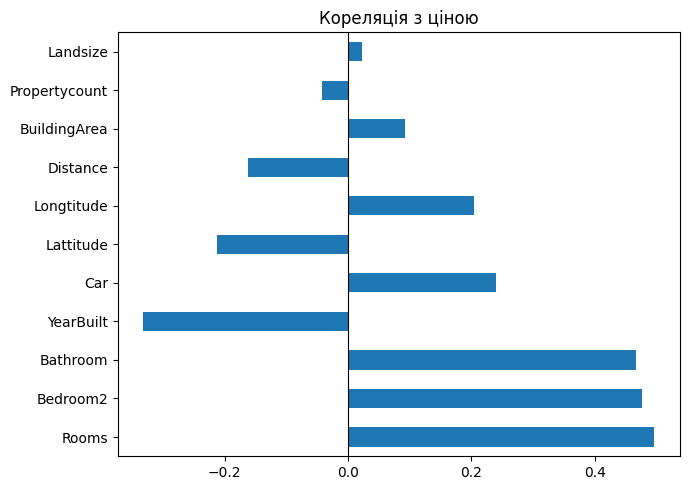

In [41]:
corr_price.plot(kind='barh', figsize=(7, 5), title='Кореляція з ціною')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Найсильніше з ціною пов'язані розмір житла — Rooms (0.50), Bedroom2 (0.48), Bathroom (0.47). Це одна група ознак, яка описує одне й те саме: чим більше житло, тим воно дорожче.
На другому місці — вік будинку: YearBuilt (−0.33). Знак від'ємний — старіші будинки дорожчі. Для Мельбурна це характерно: вікторіанські будинки у внутрішніх районах є преміальним товаром.
Локація (Lattitude −0.21, Longtitude 0.20, Distance −0.16) — помірний вплив. Від'ємна кореляція з Distance підтверджує: ближче до центру = дорожче.
Площа (BuildingArea 0.09, Landsize 0.02) — майже не впливає як лінійна ознака. Це не означає, що площа неважлива — просто лінійна кореляція її не вловлює через викиди і пропуски.

пошук майже-дублікатів: подивіться на повну матрицю кореляцій  
- num.corr() (можна .round(2))
- знайдіть пари з дуже високим зв'язком (наприклад, Rooms і Bedroom2)

In [42]:
print(num.corr().round(2))


               Rooms  Price  Distance  Bedroom2  Bathroom   Car  Landsize  BuildingArea  YearBuilt  Lattitude  \
Rooms           1.00   0.50      0.29      0.94      0.59  0.41      0.00          0.12      -0.07       0.02   
Price           0.50   1.00     -0.16      0.48      0.47  0.24      0.02          0.09      -0.33      -0.21   
Distance        0.29  -0.16      1.00      0.30      0.13  0.26      0.01          0.10       0.25      -0.13   
Bedroom2        0.94   0.48      0.30      1.00      0.58  0.41      0.00          0.12      -0.05       0.02   
Bathroom        0.59   0.47      0.13      0.58      1.00  0.32      0.03          0.11       0.15      -0.07   
Car             0.41   0.24      0.26      0.41      0.32  1.00      0.02          0.10       0.11      -0.00   
Landsize        0.00   0.02      0.01      0.00      0.03  0.02      1.00          0.50       0.08       0.01   
BuildingArea    0.12   0.09      0.10      0.12      0.11  0.10      0.50          1.00       0.

Після графіків і чисел **запишіть словами** 2-3 висновки: який тип житла дорожчий, як впливає відстань, які ознаки майже дублюються.

1. Rooms і Bedroom2 — майже одне й те саме.

Кореляція 0.94 — це майже повний дублікат. Обидві ознаки описують розмір житла, але Bedroom2 ще й має більше пропусків. У моделі залишаємо лише Rooms, Bedroom2 прибираємо.
2. Відстань від центру впливає на ціну слабше, ніж очікувалось.

Distance ↔ Price = −0.16 — зв'язок є і знак правильний (далі = дешевше), але він помірний. Цікаво, що Distance краще корелює з Rooms (0.29) — у передмістях будинки більші, але не обов'язково дорожчі.
3. Landsize і BuildingArea не впливають на ціну, але пов'язані між собою.

Landsize ↔ Price = 0.02 — нуль. BuildingArea ↔ Price = 0.09 — майже нуль. Зате Landsize ↔ BuildingArea = 0.50 — помірний зв'язок між собою. Площа ділянки і площа забудови без урахування локації ціну не пояснюють — у центрі маленька квартира коштує більше ніж великий будинок на околиці.You've used 90% of your session limitUpgrade

1. Rooms і Bedroom2 — майже одне й те саме.

Кореляція 0.94 — це майже повний дублікат. Обидві ознаки описують розмір житла, але Bedroom2 ще й має більше пропусків. У моделі залишаємо лише Rooms, Bedroom2 прибираємо.
2. Відстань від центру впливає на ціну слабше, ніж очікувалось.

Distance ↔ Price = −0.16 — зв'язок є і знак правильний (далі = дешевше), але він помірний. Цікаво, що Distance краще корелює з Rooms (0.29) — у передмістях будинки більші, але не обов'язково дорожчі.
3. Landsize і BuildingArea не впливають на ціну, але пов'язані між собою.

Landsize ↔ Price = 0.02 — нуль. BuildingArea ↔ Price = 0.09 — майже нуль. Зате Landsize ↔ BuildingArea = 0.50 — помірний зв'язок між собою. Площа ділянки і площа забудови без урахування локації ціну не пояснюють — у центрі маленька квартира коштує більше ніж великий будинок на околиці.  
Найважливіше: ознака не повинна "підглядати" у ціль. "Ціна за кімнату" рахується з `Price`, якої в реальному прогнозі ще немає - це помилка (витік).


```python
fe = clean.copy()

1) частини дати продажу
- рік: fe["sale_year"] = fe["Date"].dt.year
- місяць: за аналогією дістаньте .dt.month

In [43]:
fe = df.copy()

fe['sale_year'] = fe['Date'].dt.year
fe['sale_month'] = fe['Date'].dt.month

print(fe[['Date', 'sale_year', 'sale_month']].head())

        Date  sale_year  sale_month
0 2016-12-03       2016          12
1 2016-02-04       2016           2
2 2017-03-04       2017           3
3 2017-03-04       2017           3
4 2016-06-04       2016           6


 2) вік будинку на момент продажу
- це рік продажу мінус рік побудови (YearBuilt)
- підстрахуйтесь: якщо вийшло від'ємне число, замініть на np.nan